# Tech Careers: Insights from the Stack Overflow 2025 Developer Survey

This notebook follows the **CRISP-DM** process to answer three key business questions using the Stack Overflow 2025 Developer Survey data.

---
## 1. Business Understanding

We investigate three questions about modern tech careers:

1. **What factors predict developer salary?** — Build a regression model on `ConvertedCompYearly` to understand which experience, education, and technology factors drive compensation.

2. **Which tech skills are most associated with job satisfaction?** — Classify developers as *Satisfied* vs *Not Satisfied* (based on `JobSat` score) and identify which profile features (remote work, AI usage, experience, salary) predict satisfaction.

3. **Can we predict if a developer works remotely based on their profile?** — Build a classifier on `RemoteWork` using developer type, education, experience, and organizational factors.

---
## 2. Data Understanding / Exploratory Data Analysis

In [26]:
%matplotlib inline
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier, GradientBoostingClassifier
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (mean_absolute_error, mean_squared_error, r2_score,
                             accuracy_score, precision_score, recall_score, f1_score,
                             classification_report, ConfusionMatrixDisplay)
import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

os.makedirs('charts', exist_ok=True)

In [27]:
# Load the dataset
df = pd.read_csv('data/survey_result_2025.csv', encoding='utf-8', low_memory=False)
print(f'Dataset shape: {df.shape}')
print(f'Rows: {df.shape[0]:,}  |  Columns: {df.shape[1]}')
df.head(3)

Dataset shape: (49191, 172)
Rows: 49,191  |  Columns: 172


,ResponseId,MainBranch,Age,EdLevel,Employment,EmploymentAddl,WorkExp,LearnCodeChoose,LearnCode,LearnCodeAI,...,AIAgentOrchestration,AIAgentOrchWrite,AIAgentObserveSecure,AIAgentObsWrite,AIAgentExternal,AIAgentExtWrite,AIHuman,AIOpen,ConvertedCompYearly,JobSat
0,1,I am a developer by profession,25-34 years old,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Employed,"Caring for dependents (children, elderly, etc.)",8.0,"Yes, I am not new to coding but am learning ne...",Online Courses or Certification (includes all ...,"Yes, I learned how to use AI-enabled tools for...",...,Vertex AI,NaN,NaN,NaN,ChatGPT,NaN,When I don’t trust AI’s answers,"Troubleshooting, profiling, debugging",61256.0,10.0
1,2,I am a developer by profession,25-34 years old,"Associate degree (A.A., A.S., etc.)",Employed,NaN,2.0,"Yes, I am not new to coding but am learning ne...",Online Courses or Certification (includes all ...,"Yes, I learned how to use AI-enabled tools for...",...,NaN,NaN,NaN,NaN,NaN,NaN,When I don’t trust AI’s answers;When I want to...,All skills. AI is a flop.,104413.0,9.0
2,3,I am a developer by profession,35-44 years old,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)","Independent contractor, freelancer, or self-em...",None of the above,10.0,"Yes, I am not new to coding but am learning ne...",Online Courses or Certification (includes all ...,"Yes, I learned how to use AI-enabled tools for...",...,NaN,NaN,NaN,NaN,ChatGPT;Claude Code;GitHub Copilot;Google Gemini,NaN,When I don’t trust AI’s answers;When I want to...,"Understand how things actually work, problem s...",53061.0,8.0


In [28]:
# Data types overview
print('Data types:\n')
print(df.dtypes.value_counts())
print('\n--- Numeric columns ---')
print(df.select_dtypes(include='number').columns.tolist())

Data types:

str        119
float64     52
int64        1
Name: count, dtype: int64

--- Numeric columns ---
['ResponseId', 'WorkExp', 'YearsCode', 'TechEndorse_1', 'TechEndorse_2', 'TechEndorse_3', 'TechEndorse_4', 'TechEndorse_5', 'TechEndorse_6', 'TechEndorse_7', 'TechEndorse_8', 'TechEndorse_9', 'TechEndorse_13', 'TechOppose_1', 'TechOppose_2', 'TechOppose_3', 'TechOppose_5', 'TechOppose_7', 'TechOppose_9', 'TechOppose_11', 'TechOppose_13', 'TechOppose_16', 'TechOppose_15', 'JobSatPoints_1', 'JobSatPoints_2', 'JobSatPoints_3', 'JobSatPoints_4', 'JobSatPoints_5', 'JobSatPoints_6', 'JobSatPoints_7', 'JobSatPoints_8', 'JobSatPoints_9', 'JobSatPoints_10', 'JobSatPoints_11', 'JobSatPoints_13', 'JobSatPoints_14', 'JobSatPoints_15', 'JobSatPoints_16', 'ToolCountWork', 'ToolCountPersonal', 'CompTotal', 'SO_Actions_1', 'SO_Actions_16', 'SO_Actions_3', 'SO_Actions_4', 'SO_Actions_5', 'SO_Actions_6', 'SO_Actions_9', 'SO_Actions_7', 'SO_Actions_10', 'SO_Actions_15', 'ConvertedCompYearly', 'Job

In [29]:
# Missing values summary (top 30 columns with most missing)
missing = df.isnull().sum().sort_values(ascending=False)
missing_pct = (missing / len(df) * 100).round(1)
missing_df = pd.DataFrame({'Missing': missing, 'Pct': missing_pct})
print('Top 30 columns by missing values:\n')
print(missing_df.head(30))

Top 30 columns by missing values:

                                Missing   Pct
AIAgentObsWrite                   48927  99.5
SOTagsWant Entry                  48761  99.1
SOTagsHaveEntry                   48733  99.1
AIModelsWantEntry                 48716  99.0
AIAgentOrchWrite                  48713  99.0
JobSatPoints_15_TEXT              48527  98.7
AIAgentKnowWrite                  48425  98.4
AIModelsHaveEntry                 48415  98.4
SO_Actions_15_TEXT                48368  98.3
AIAgentExtWrite                   48332  98.3
CommPlatformWantEntr              48007  97.6
CommPlatformHaveEntr              47715  97.0
DatabaseWantEntry                 47658  96.9
OfficeStackWantEntry              47574  96.7
TechOppose_15_TEXT                47544  96.7
TechEndorse_13_TEXT               47182  95.9
DevEnvWantEntry                   47079  95.7
DatabaseHaveEntry                 47041  95.6
OfficeStackHaveEntry              46602  94.7
WebframeWantEntry                 46561  94.7

### Data Quality Considerations

Key data quality observations:

- **High missingness**: Several columns have >50% missing values (e.g., compensation fields, optional demographic questions). We handle this per-model by dropping rows only where the target variable is missing, and filling feature NaN values with medians (numeric) or 'Unknown' (categorical) to maximize usable sample size.
- **Self-reported data**: All survey responses are self-reported, which introduces potential inaccuracies — particularly for compensation (`ConvertedCompYearly`), which may be misunderstood or misreported across currencies.
- **Multi-select columns**: Columns like `DevType` and `LanguageHaveWorkedWith` contain semicolon-separated lists, requiring special handling (exploding or one-hot encoding).
- **Compensation outliers**: The salary distribution is heavily right-skewed with extreme values, necessitating percentile clipping before modeling.
- **Selection bias**: Stack Overflow survey respondents skew toward web developers, English speakers, and certain geographies — findings may not generalize to all developers globally.

### Distribution Plots

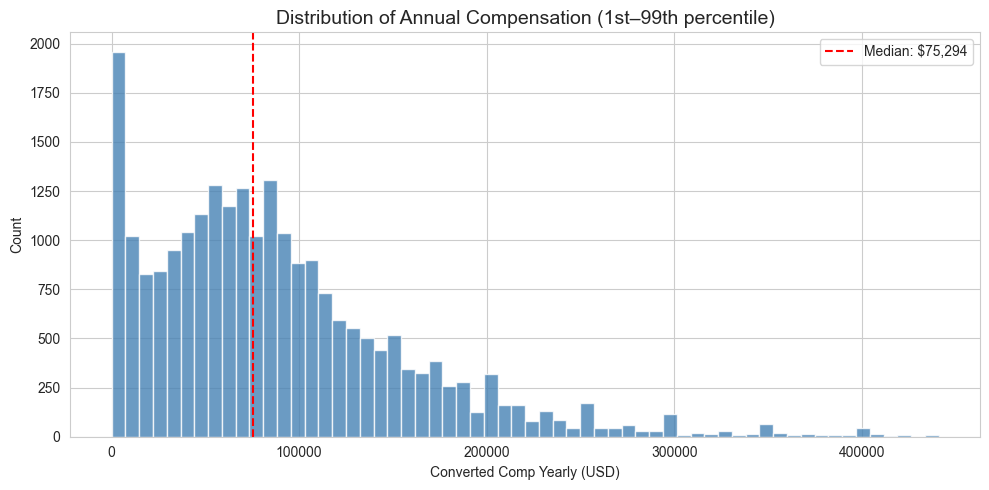

Salary stats — Mean: $88,200 | Median: $75,294


In [30]:
# Distribution of ConvertedCompYearly (clipped for visualization)
salary = df['ConvertedCompYearly'].dropna()
salary_clipped = salary[salary.between(salary.quantile(0.01), salary.quantile(0.99))]

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(salary_clipped, bins=60, color='steelblue', edgecolor='white', alpha=0.8)
ax.set_title('Distribution of Annual Compensation (1st–99th percentile)', fontsize=14)
ax.set_xlabel('Converted Comp Yearly (USD)')
ax.set_ylabel('Count')
ax.axvline(salary_clipped.median(), color='red', linestyle='--', label=f'Median: ${salary_clipped.median():,.0f}')
ax.legend()
plt.tight_layout()
plt.savefig('charts/salary_distribution.png', bbox_inches='tight', dpi=150)
plt.show()
print(f'Salary stats — Mean: ${salary_clipped.mean():,.0f} | Median: ${salary_clipped.median():,.0f}')

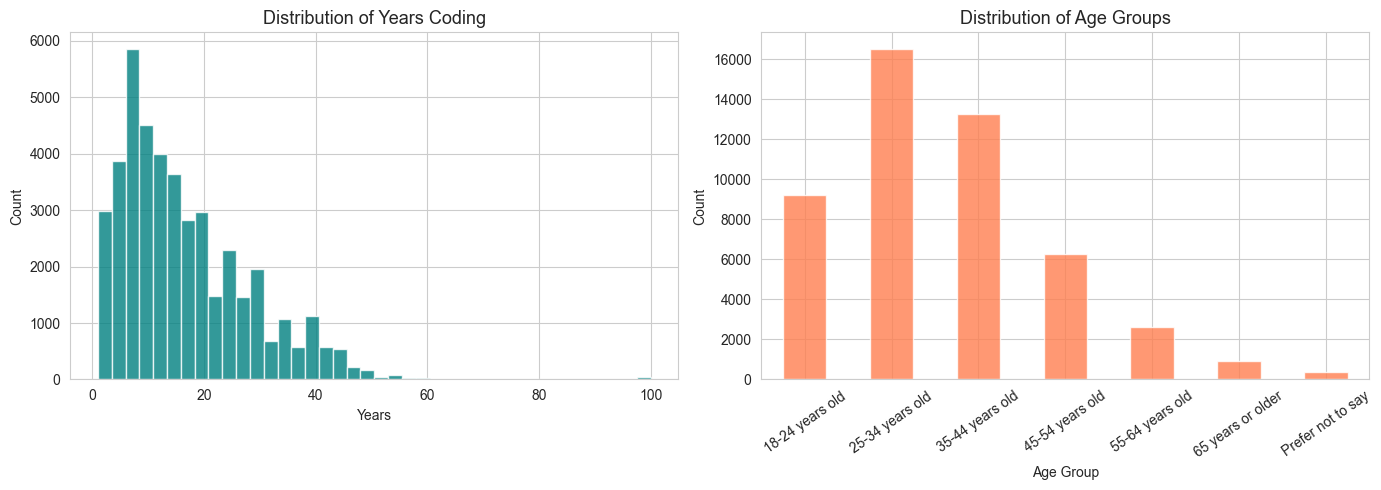

In [31]:
# Distribution of YearsCode and WorkExp
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df['YearsCode'].dropna().hist(bins=40, ax=axes[0], color='teal', edgecolor='white', alpha=0.8)
axes[0].set_title('Distribution of Years Coding', fontsize=13)
axes[0].set_xlabel('Years')
axes[0].set_ylabel('Count')

age_order = ['18-24 years old', '25-34 years old', '35-44 years old',
             '45-54 years old', '55-64 years old', '65 years or older', 'Prefer not to say']
age_counts = df['Age'].value_counts().reindex(age_order).dropna()
age_counts.plot(kind='bar', ax=axes[1], color='coral', edgecolor='white', alpha=0.8)
axes[1].set_title('Distribution of Age Groups', fontsize=13)
axes[1].set_xlabel('Age Group')
axes[1].set_ylabel('Count')
axes[1].tick_params(axis='x', rotation=35)

plt.tight_layout()
plt.show()

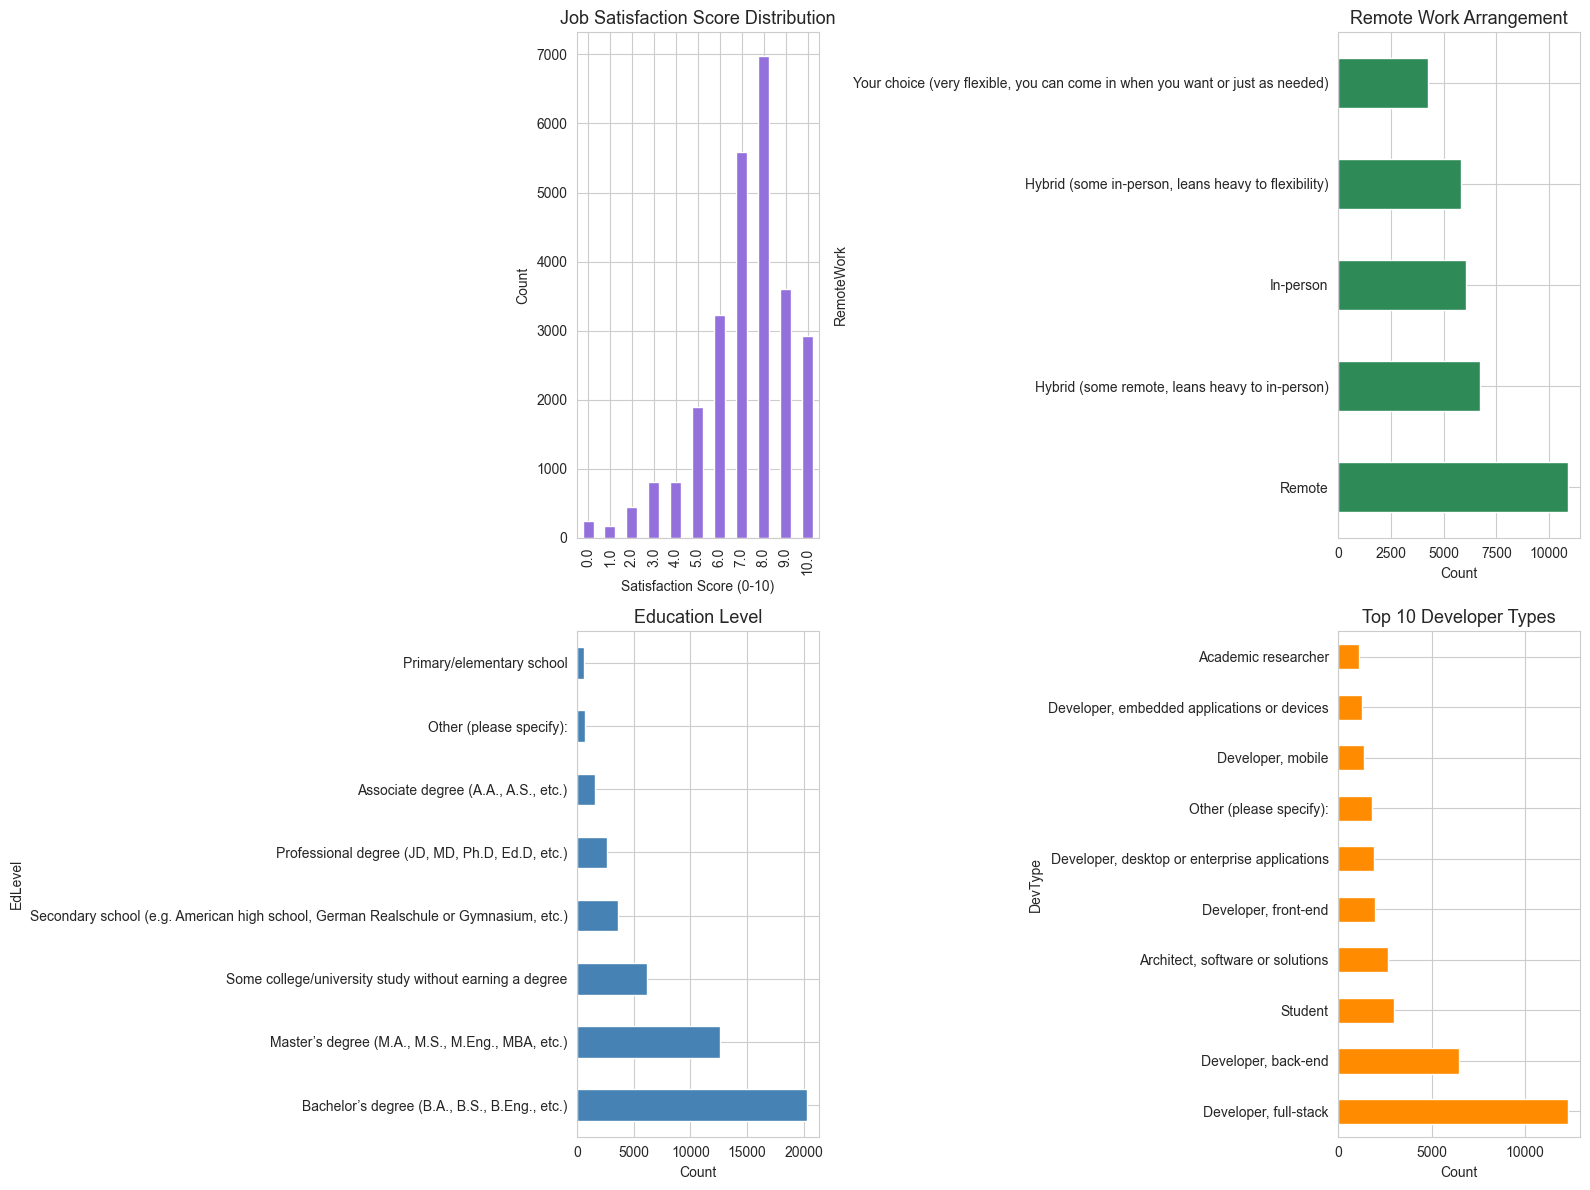

In [32]:
# Bar charts for JobSat, RemoteWork, EdLevel, DevType (top 10)
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# JobSat distribution
jobsat = df['JobSat'].dropna()
jobsat.value_counts().sort_index().plot(kind='bar', ax=axes[0, 0], color='mediumpurple', edgecolor='white')
axes[0, 0].set_title('Job Satisfaction Score Distribution', fontsize=13)
axes[0, 0].set_xlabel('Satisfaction Score (0-10)')
axes[0, 0].set_ylabel('Count')

# RemoteWork
df['RemoteWork'].value_counts().plot(kind='barh', ax=axes[0, 1], color='seagreen', edgecolor='white')
axes[0, 1].set_title('Remote Work Arrangement', fontsize=13)
axes[0, 1].set_xlabel('Count')

# EdLevel
df['EdLevel'].value_counts().head(8).plot(kind='barh', ax=axes[1, 0], color='steelblue', edgecolor='white')
axes[1, 0].set_title('Education Level', fontsize=13)
axes[1, 0].set_xlabel('Count')

# DevType top 10 (multi-select, split on ;)
devtype_series = df['DevType'].dropna().str.split(';').explode().str.strip()
devtype_series.value_counts().head(10).plot(kind='barh', ax=axes[1, 1], color='darkorange', edgecolor='white')
axes[1, 1].set_title('Top 10 Developer Types', fontsize=13)
axes[1, 1].set_xlabel('Count')

plt.tight_layout()
plt.show()

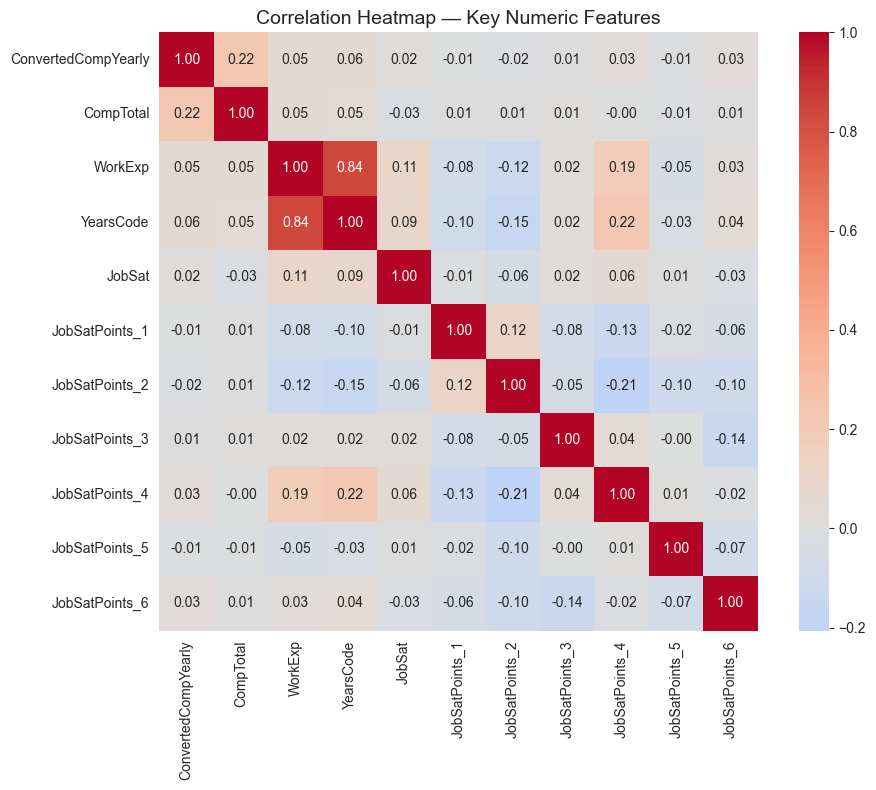

In [33]:
# Correlation heatmap for numeric columns
numeric_cols = df.select_dtypes(include='number').columns.tolist()
# Select a meaningful subset to keep the heatmap readable
key_numeric = [c for c in ['ConvertedCompYearly', 'CompTotal', 'WorkExp', 'YearsCode', 'JobSat',
                           'JobSatPoints_1', 'JobSatPoints_2', 'JobSatPoints_3', 'JobSatPoints_4',
                           'JobSatPoints_5', 'JobSatPoints_6'] if c in numeric_cols]

corr = df[key_numeric].corr()
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, ax=ax, square=True)
ax.set_title('Correlation Heatmap — Key Numeric Features', fontsize=14)
plt.tight_layout()
plt.show()

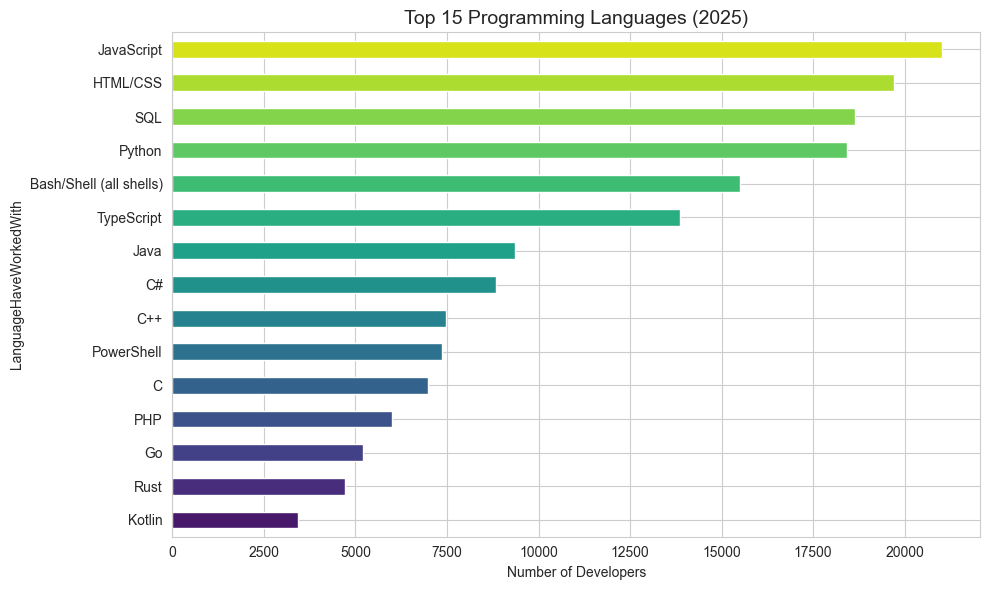

In [34]:
# Top 15 programming languages by number of developers
lang_col = 'LanguageHaveWorkedWith'
lang_exploded = df[lang_col].dropna().str.split(';').explode().str.strip()
top_langs = lang_exploded.value_counts().head(15)

fig, ax = plt.subplots(figsize=(10, 6))
top_langs.sort_values().plot(kind='barh', ax=ax, color=sns.color_palette('viridis', len(top_langs)), edgecolor='white')
ax.set_title('Top 15 Programming Languages (2025)', fontsize=14)
ax.set_xlabel('Number of Developers')
plt.tight_layout()
plt.savefig('charts/top_languages.png', bbox_inches='tight', dpi=150)
plt.show()

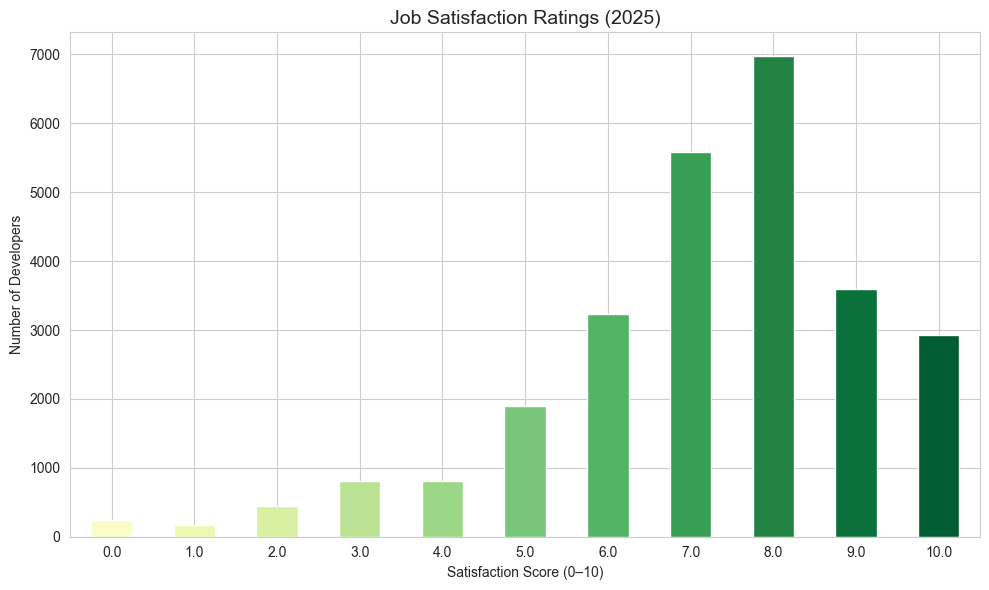

In [35]:
# Job Satisfaction Ratings — standalone bar chart for blog
jobsat_counts = df['JobSat'].dropna().value_counts().sort_index()

fig, ax = plt.subplots(figsize=(10, 6))
colors = sns.color_palette('YlGn', len(jobsat_counts))
jobsat_counts.plot(kind='bar', ax=ax, color=colors, edgecolor='white')
ax.set_title('Job Satisfaction Ratings (2025)', fontsize=14)
ax.set_xlabel('Satisfaction Score (0–10)')
ax.set_ylabel('Number of Developers')
ax.tick_params(axis='x', rotation=0)
plt.tight_layout()
plt.savefig('charts/job_satisfaction_bar.png', bbox_inches='tight', dpi=150)
plt.show()

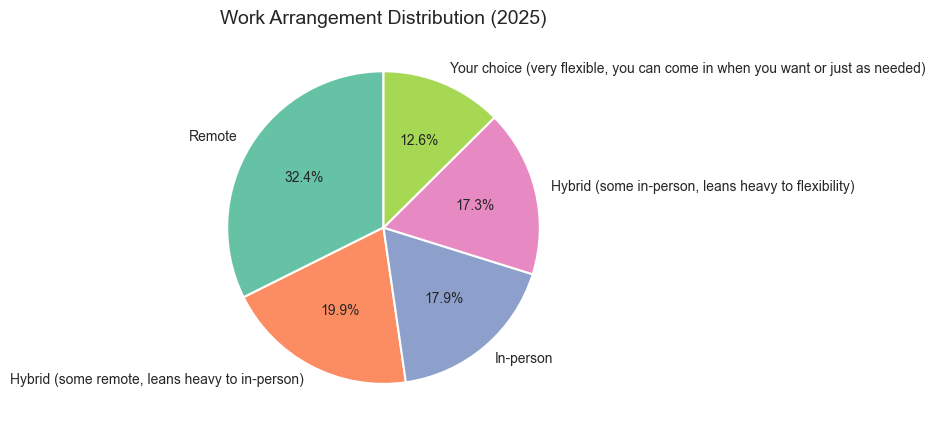

In [36]:
# Remote Work Arrangement — pie chart for blog
remote_counts = df['RemoteWork'].dropna().value_counts()

fig, ax = plt.subplots(figsize=(8, 8))
ax.pie(remote_counts, labels=remote_counts.index, autopct='%1.1f%%',
       colors=sns.color_palette('Set2', len(remote_counts)),
       startangle=90, wedgeprops={'edgecolor': 'white', 'linewidth': 1.5})
ax.set_title('Work Arrangement Distribution (2025)', fontsize=14)
plt.tight_layout()
plt.savefig('charts/remote_work_pie.png', bbox_inches='tight', dpi=150)
plt.show()

---
## 3. Data Preparation

We prepare three separate datasets, one per model, applying appropriate cleaning and feature engineering.

In [37]:
def one_hot_multiselect(series, top_n=15, sep=';'):
    """One-hot encode a multi-select column, keeping only the top_n most common values.

    Parameters:
        series (pd.Series): Column with semicolon-separated multi-select values.
        top_n (int): Number of most common values to retain as binary columns.
        sep (str): Delimiter used to separate values within each cell.

    Returns:
        pd.DataFrame: Binary indicator columns for the top_n most frequent values.
    """
    exploded = series.dropna().str.split(sep).explode().str.strip()
    top_vals = exploded.value_counts().head(top_n).index.tolist()
    result = pd.DataFrame(index=series.index)
    for val in top_vals:
        col_name = val.replace(' ', '_').replace('/', '_').replace('.', '')
        result[col_name] = series.fillna('').str.contains(val.replace('(', '\\(').replace(')', '\\)').replace('+', '\\+'),
                                                           regex=True, na=False).astype(int)
    return result


def prepare_features(df, categorical_cols, numeric_cols, fill_value='Unknown'):
    """Fill missing values and label-encode categorical columns for tree-based models.

    This consolidates the repeated preprocessing pattern used across all three models:
    1. Fills categorical NaN with a constant to preserve rows instead of dropping them.
    2. Fills numeric NaN with column median to preserve distribution shape and handle skew.
    3. Label-encodes categoricals into integers — suitable for tree-based models that
       split on thresholds and don't assume ordinal meaning.

    Parameters:
        df (pd.DataFrame): DataFrame to process (modified in-place).
        categorical_cols (list[str]): Categorical column names to fill and encode.
        numeric_cols (list[str]): Numeric column names to fill with median.
        fill_value (str): Constant to fill categorical NaN values (default 'Unknown').

    Returns:
        tuple: (modified DataFrame, dict mapping column name to fitted LabelEncoder)
    """
    for col in categorical_cols:
        df[col] = df[col].fillna(fill_value)
    # Using median fill to preserve distribution and handle skewed data
    for col in numeric_cols:
        df[col] = df[col].fillna(df[col].median())
    # Using LabelEncoder for tree-based models — they handle arbitrary integer encoding
    # without assuming ordinality, unlike linear models which would need one-hot encoding
    le_dict = {}
    for col in categorical_cols:
        le = LabelEncoder()
        df[col + '_enc'] = le.fit_transform(df[col].astype(str))
        le_dict[col] = le
    return df, le_dict


def plot_feature_importance(model, feature_names, top_n=15, title='Feature Importances', color='steelblue', save_path=None):
    """Plot top N feature importances as a horizontal bar chart.

    Parameters:
        model: Fitted sklearn model with a feature_importances_ attribute.
        feature_names (list or pd.Index): Feature names matching model input order.
        top_n (int): Number of top features to display.
        title (str): Chart title.
        color (str): Bar color.
        save_path (str or None): If provided, save the figure to this path.

    Returns:
        pd.Series: All feature importances indexed by feature name.
    """
    importances = pd.Series(model.feature_importances_, index=feature_names)
    top = importances.nlargest(top_n)
    fig, ax = plt.subplots(figsize=(10, 6))
    top.sort_values().plot(kind='barh', ax=ax, color=color, edgecolor='white')
    ax.set_title(title, fontsize=14)
    ax.set_xlabel('Importance')
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, bbox_inches='tight', dpi=150)
    plt.show()
    return importances


print('Helper functions defined: one_hot_multiselect, prepare_features, plot_feature_importance')

Helper functions defined: one_hot_multiselect, prepare_features, plot_feature_importance


### 3a. Salary Prediction Dataset

In [38]:
# --- Dataset for Model 1: Salary Prediction ---
df_salary = df.dropna(subset=['ConvertedCompYearly']).copy()

# Clipping to 1st–99th percentile to remove extreme outliers that distort model training
# (e.g., $0 entries or multi-million dollar compensation that skew the distribution)
low = df_salary['ConvertedCompYearly'].quantile(0.01)
high = df_salary['ConvertedCompYearly'].quantile(0.99)
df_salary = df_salary[df_salary['ConvertedCompYearly'].between(low, high)].copy()
print(f'Salary dataset after outlier removal: {df_salary.shape}')

# One-hot encode top 15 programming languages — captures which tech skills impact salary
lang_ohe = one_hot_multiselect(df_salary['LanguageHaveWorkedWith'], top_n=15)
lang_ohe.columns = ['lang_' + c for c in lang_ohe.columns]

# Take the first listed DevType as primary role — simplifies multi-select into single category
df_salary['DevType_primary'] = df_salary['DevType'].fillna('Unknown').str.split(';').str[0].str.strip()

# Use prepare_features helper to handle missing values and label-encode categoricals
# This replaces the repeated fill-NaN + LabelEncoder loop pattern
cat_features = ['EdLevel', 'RemoteWork', 'OrgSize', 'Country', 'DevType_primary']
num_features = ['YearsCode', 'WorkExp']
df_salary, le_dict_salary = prepare_features(df_salary, cat_features, num_features)

# Assemble feature matrix combining numeric, encoded categorical, and language OHE features
X_salary = pd.concat([df_salary[['YearsCode', 'WorkExp'] + [c + '_enc' for c in cat_features]].reset_index(drop=True),
                       lang_ohe.reset_index(drop=True)], axis=1)
y_salary = df_salary['ConvertedCompYearly'].reset_index(drop=True)

# Standard scaling — normalizes feature ranges so no single feature dominates by magnitude
scaler_salary = StandardScaler()
X_salary_scaled = pd.DataFrame(scaler_salary.fit_transform(X_salary), columns=X_salary.columns)

print(f'Features: {X_salary_scaled.shape[1]}  |  Samples: {X_salary_scaled.shape[0]}')
X_salary_scaled.head(3)

Salary dataset after outlier removal: (23474, 172)
Features: 22  |  Samples: 23474


,YearsCode,WorkExp,EdLevel_enc,RemoteWork_enc,OrgSize_enc,Country_enc,DevType_primary_enc,lang_JavaScript,lang_HTML_CSS,lang_SQL,...,lang_TypeScript,lang_C#,lang_Java,lang_PowerShell,lang_C++,lang_PHP,lang_C,lang_Go,lang_Rust,lang_Kotlin
0,-0.335825,-0.561935,-0.225766,0.393533,-0.303399,1.050160,0.711443,-1.287920,-1.171968,0.870683,...,-0.874925,-0.607113,-1.505231,-0.537983,-0.486663,-0.454919,-1.697623,-0.431804,-0.385564,-0.334484
1,-0.701175,-1.162148,-1.149934,-1.511558,0.352370,0.089455,-0.231488,-1.287920,-1.171968,-1.148524,...,-0.874925,-0.607113,0.664350,-0.537983,-0.486663,-0.454919,-1.697623,-0.431804,-0.385564,-0.334484
2,-0.518500,-0.361865,-0.687850,1.028563,1.663908,1.050160,0.239977,0.776446,0.853266,-1.148524,...,1.142955,-0.607113,0.664350,-0.537983,-0.486663,-0.454919,0.589059,-0.431804,-0.385564,-0.334484


### 3b. Job Satisfaction Dataset

In [39]:
# --- Dataset for Model 2: Job Satisfaction Classification ---
df_sat = df.dropna(subset=['JobSat']).copy()

# Binary target: threshold at 7 (out of 10) — separates clearly satisfied from neutral/dissatisfied
# Chosen because scores 7-10 represent active satisfaction vs 0-6 which includes ambivalent responses
df_sat['JobSat_binary'] = (df_sat['JobSat'] >= 7).astype(int)
print('Job Satisfaction class distribution:')
print(df_sat['JobSat_binary'].value_counts().rename({1: 'Satisfied', 0: 'Not Satisfied'}))

# Use prepare_features helper to handle missing values and label-encode categoricals
# This replaces the repeated fill-NaN + LabelEncoder loop pattern
sat_cat_cols = ['RemoteWork', 'EdLevel', 'OrgSize', 'Industry', 'AISelect']
sat_num_cols = ['WorkExp', 'YearsCode', 'ConvertedCompYearly']
df_sat, le_dict_sat = prepare_features(df_sat, sat_cat_cols, sat_num_cols)

# Feature matrix: numeric features + encoded categoricals
X_sat = df_sat[['WorkExp', 'YearsCode', 'ConvertedCompYearly'] +
               [c + '_enc' for c in sat_cat_cols]].reset_index(drop=True)
y_sat = df_sat['JobSat_binary'].reset_index(drop=True)

print(f'\nFeatures: {X_sat.shape[1]}  |  Samples: {X_sat.shape[0]}')

Job Satisfaction class distribution:
JobSat_binary
Satisfied        19084
Not Satisfied     7586
Name: count, dtype: int64

Features: 8  |  Samples: 26670


### 3c. Remote Work Prediction Dataset

In [40]:
# --- Dataset for Model 3: Remote Work Prediction ---
df_remote = df.dropna(subset=['RemoteWork']).copy()

# Simplify to 3 classes to reduce sparsity — merging flexible/hybrid variants into one
# category since the distinction between hybrid sub-types is too granular for prediction
remote_map = {
    'Remote': 'Remote',
    'In-person': 'In-person',
    'Hybrid (some in-person, leans heavy to flexibility)': 'Hybrid',
    'Hybrid (some remote, leans heavy to in-person)': 'Hybrid',
    'Your choice (very flexible, you can come in when you want or just as needed)': 'Hybrid'
}
df_remote['RemoteWork_simple'] = df_remote['RemoteWork'].map(remote_map)
print('Remote Work class distribution:')
print(df_remote['RemoteWork_simple'].value_counts())

# Take the first listed DevType as primary role for simpler encoding
df_remote['DevType_primary'] = df_remote['DevType'].fillna('Unknown').str.split(';').str[0].str.strip()

# Use prepare_features helper to handle missing values and label-encode categoricals
# This replaces the repeated fill-NaN + LabelEncoder loop pattern
remote_cat_cols = ['EdLevel', 'Country', 'OrgSize', 'Industry', 'DevType_primary']
remote_num_cols = ['YearsCode', 'WorkExp']
df_remote, le_dict_remote = prepare_features(df_remote, remote_cat_cols, remote_num_cols)

# Encode target variable — LabelEncoder maps class strings to integers for sklearn
le_target_remote = LabelEncoder()
y_remote = pd.Series(le_target_remote.fit_transform(df_remote['RemoteWork_simple']))
X_remote = df_remote[['YearsCode', 'WorkExp'] + [c + '_enc' for c in remote_cat_cols]].reset_index(drop=True)

print(f'\nFeatures: {X_remote.shape[1]}  |  Samples: {X_remote.shape[0]}')
print('Target classes:', le_target_remote.classes_.tolist())

Remote Work class distribution:
RemoteWork_simple
Hybrid       16807
Remote       10931
In-person     6042
Name: count, dtype: int64

Features: 7  |  Samples: 33780
Target classes: ['Hybrid', 'In-person', 'Remote']


---
## 4. Modeling

### Model 1 — Salary Prediction (Random Forest Regressor)

**Why Random Forest?** Random Forest handles non-linear relationships well and is robust to outliers remaining after percentile clipping. It provides built-in feature importance rankings, requires minimal hyperparameter tuning, and handles mixed feature types (numeric + label-encoded categorical) effectively. For regression on tabular survey data with many categorical features, tree ensembles consistently outperform linear models.

In [41]:
X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(
    X_salary_scaled, y_salary, test_size=0.2, random_state=42)

rf_salary = RandomForestRegressor(n_estimators=150, max_depth=15, random_state=42, n_jobs=-1)
rf_salary.fit(X_train_s, y_train_s)

y_pred_s = rf_salary.predict(X_test_s)

r2 = r2_score(y_test_s, y_pred_s)
mae = mean_absolute_error(y_test_s, y_pred_s)
rmse = np.sqrt(mean_squared_error(y_test_s, y_pred_s))

print('=== Salary Prediction Results ===')
print(f'R² Score:  {r2:.4f}')
print(f'MAE:       ${mae:,.0f}')
print(f'RMSE:      ${rmse:,.0f}')

# 5-fold cross-validation to check generalization — reduces risk of overfitting to a single split
cv_scores_salary = cross_val_score(rf_salary, X_salary_scaled, y_salary, cv=5, scoring='r2', n_jobs=-1)
print(f'\n5-Fold Cross-Validation R²: {cv_scores_salary.mean():.4f} ± {cv_scores_salary.std():.4f}')
print(f'Individual fold scores: {[f"{s:.4f}" for s in cv_scores_salary]}')

=== Salary Prediction Results ===
R² Score:  0.5122
MAE:       $33,279
RMSE:      $48,303

5-Fold Cross-Validation R²: 0.5058 ± 0.0163
Individual fold scores: ['0.4822', '0.5006', '0.4977', '0.5223', '0.5260']


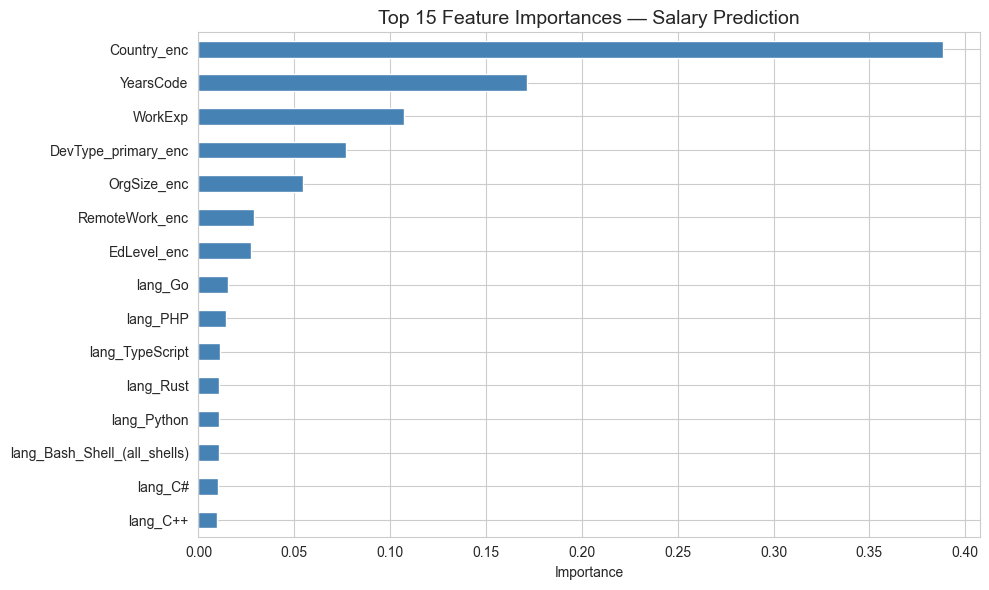

In [42]:
# Feature importance for salary model — identifies which variables most influence predictions
importances_s = plot_feature_importance(
    rf_salary, X_salary_scaled.columns, top_n=15,
    title='Top 15 Feature Importances — Salary Prediction', color='steelblue',
    save_path='charts/salary_feature_importance.png')

### Model 2 — Job Satisfaction (Gradient Boosting Classifier)

**Why Gradient Boosting?** Gradient Boosting builds trees sequentially, with each tree correcting errors from the previous one. This makes it especially effective for noisy classification tasks like satisfaction prediction, where the signal-to-noise ratio is lower than in salary or remote-work prediction. It typically achieves higher accuracy than Random Forest on structured data with fewer features, and the `learning_rate` parameter provides fine-grained control over model complexity to prevent overfitting.

=== Job Satisfaction Classification Results ===
Accuracy:  0.7064
Precision: 0.7194
Recall:    0.9667
F1 Score:  0.8249

5-Fold Cross-Validation Accuracy: 0.7142 ± 0.0020
Individual fold scores: ['0.7156', '0.7126', '0.7143', '0.7115', '0.7171']


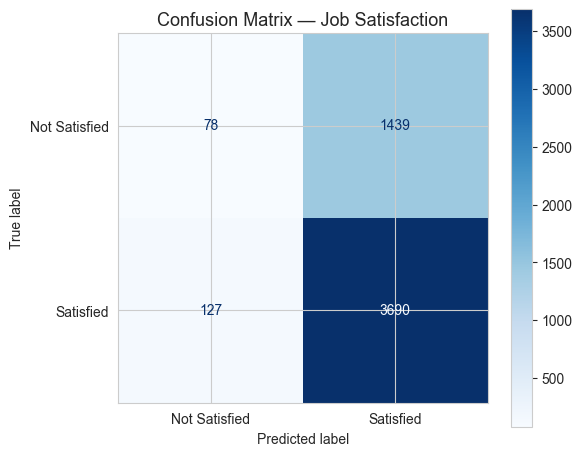

In [43]:
# Stratified split preserves class ratio in train/test sets — important for imbalanced targets
X_train_j, X_test_j, y_train_j, y_test_j = train_test_split(
    X_sat, y_sat, test_size=0.2, random_state=42, stratify=y_sat)

gb_sat = GradientBoostingClassifier(n_estimators=150, max_depth=5, learning_rate=0.1, random_state=42)
gb_sat.fit(X_train_j, y_train_j)

y_pred_j = gb_sat.predict(X_test_j)

print('=== Job Satisfaction Classification Results ===')
print(f'Accuracy:  {accuracy_score(y_test_j, y_pred_j):.4f}')
print(f'Precision: {precision_score(y_test_j, y_pred_j):.4f}')
print(f'Recall:    {recall_score(y_test_j, y_pred_j):.4f}')
print(f'F1 Score:  {f1_score(y_test_j, y_pred_j):.4f}')

# 5-fold cross-validation to verify model stability across different data splits
cv_scores_sat = cross_val_score(gb_sat, X_sat, y_sat, cv=5, scoring='accuracy', n_jobs=-1)
print(f'\n5-Fold Cross-Validation Accuracy: {cv_scores_sat.mean():.4f} ± {cv_scores_sat.std():.4f}')
print(f'Individual fold scores: {[f"{s:.4f}" for s in cv_scores_sat]}')

fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_estimator(gb_sat, X_test_j, y_test_j, ax=ax,
                                      display_labels=['Not Satisfied', 'Satisfied'], cmap='Blues')
ax.set_title('Confusion Matrix — Job Satisfaction', fontsize=13)
plt.tight_layout()
plt.show()

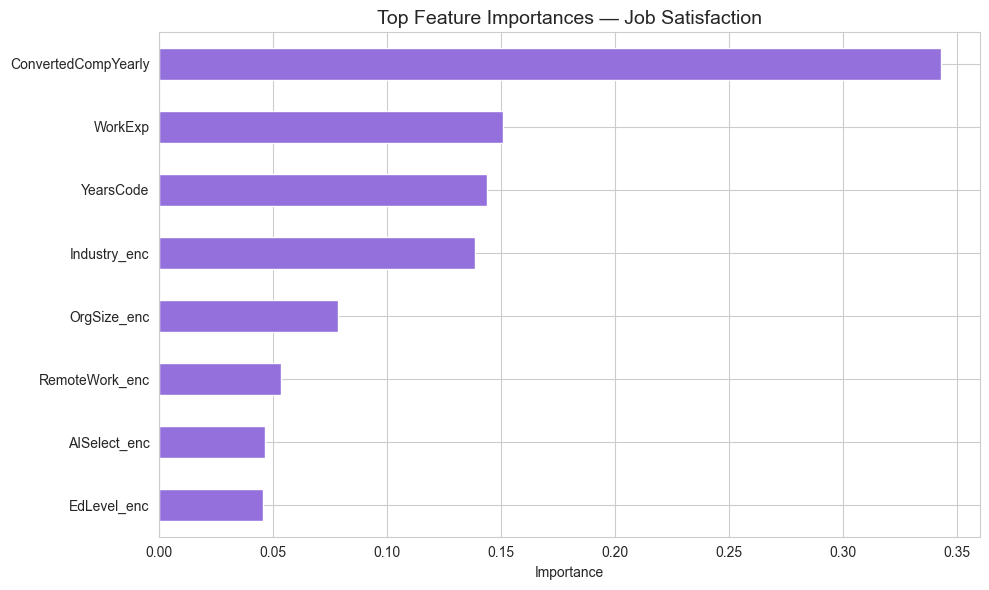

In [44]:
# Feature importance for job satisfaction model
importances_j = plot_feature_importance(
    gb_sat, X_sat.columns, top_n=10,
    title='Top Feature Importances — Job Satisfaction', color='mediumpurple')

### Model 3 — Remote Work Prediction (Random Forest Classifier)

**Why Random Forest?** For this multi-class problem (Remote/Hybrid/In-person), Random Forest is a strong baseline that handles class imbalance gracefully through bootstrap sampling. It parallelizes well (`n_jobs=-1`), provides reliable feature importances, and is less prone to overfitting than Gradient Boosting on multi-class tasks with limited distinguishing signal between classes.

=== Remote Work Classification Results ===
Accuracy: 0.5530

Classification Report:
              precision    recall  f1-score   support

      Hybrid       0.57      0.79      0.66      3362
   In-person       0.45      0.14      0.21      1208
      Remote       0.53      0.42      0.47      2186

    accuracy                           0.55      6756
   macro avg       0.52      0.45      0.45      6756
weighted avg       0.54      0.55      0.52      6756

5-Fold Cross-Validation Accuracy: 0.5468 ± 0.0031
Individual fold scores: ['0.5477', '0.5471', '0.5500', '0.5484', '0.5409']


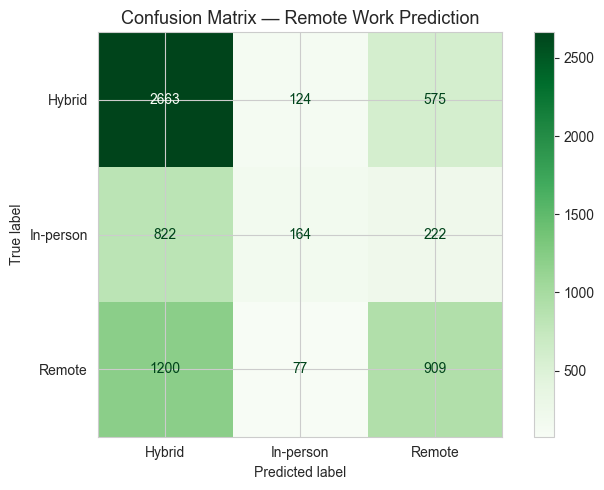

In [45]:
# Stratified split ensures each remote work class is proportionally represented
X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    X_remote, y_remote, test_size=0.2, random_state=42, stratify=y_remote)

rf_remote = RandomForestClassifier(n_estimators=150, max_depth=15, random_state=42, n_jobs=-1)
rf_remote.fit(X_train_r, y_train_r)

y_pred_r = rf_remote.predict(X_test_r)

print('=== Remote Work Classification Results ===')
print(f'Accuracy: {accuracy_score(y_test_r, y_pred_r):.4f}\n')
print('Classification Report:')
print(classification_report(y_test_r, y_pred_r, target_names=le_target_remote.classes_))

# 5-fold cross-validation to assess generalization on unseen data
cv_scores_remote = cross_val_score(rf_remote, X_remote, y_remote, cv=5, scoring='accuracy', n_jobs=-1)
print(f'5-Fold Cross-Validation Accuracy: {cv_scores_remote.mean():.4f} ± {cv_scores_remote.std():.4f}')
print(f'Individual fold scores: {[f"{s:.4f}" for s in cv_scores_remote]}')

fig, ax = plt.subplots(figsize=(7, 5))
ConfusionMatrixDisplay.from_estimator(rf_remote, X_test_r, y_test_r, ax=ax,
                                      display_labels=le_target_remote.classes_, cmap='Greens')
ax.set_title('Confusion Matrix — Remote Work Prediction', fontsize=13)
plt.tight_layout()
plt.show()

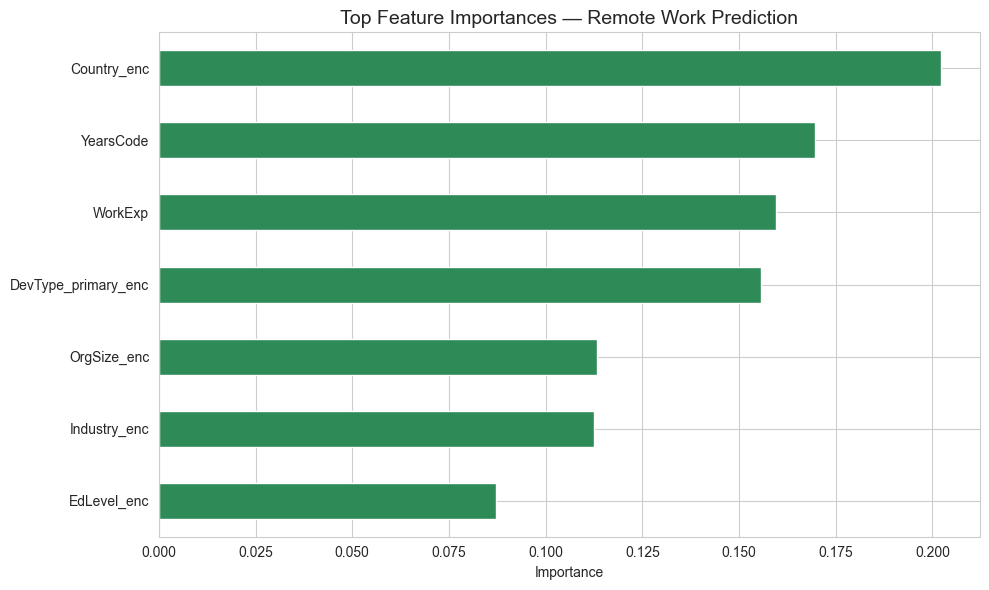

In [46]:
# Feature importance for remote work model
importances_r = plot_feature_importance(
    rf_remote, X_remote.columns, top_n=10,
    title='Top Feature Importances — Remote Work Prediction', color='seagreen')

---
## 5. Evaluation — Summary of All Models

| Model | Task | Algorithm | Key Metrics |
|-------|------|-----------|-------------|
| Salary Prediction | Regression | RandomForestRegressor | R², MAE, RMSE + 5-fold CV |
| Job Satisfaction | Binary Classification | GradientBoostingClassifier | Accuracy, F1 + 5-fold CV |
| Remote Work | Multi-class Classification | RandomForestClassifier | Accuracy, F1 + 5-fold CV |

In [47]:
print('=' * 60)
print('MODEL EVALUATION SUMMARY')
print('=' * 60)

print('\n--- Model 1: Salary Prediction ---')
print(f'  R² Score:  {r2:.4f}')
print(f'  MAE:       ${mae:,.0f}')
print(f'  RMSE:      ${rmse:,.0f}')
print(f'  5-Fold CV R²: {cv_scores_salary.mean():.4f} ± {cv_scores_salary.std():.4f}')
print(f'  Top 3 features: {", ".join(importances_s.nlargest(3).index.tolist())}')

print('\n--- Model 2: Job Satisfaction ---')
acc_j = accuracy_score(y_test_j, y_pred_j)
f1_j = f1_score(y_test_j, y_pred_j)
print(f'  Accuracy:  {acc_j:.4f}')
print(f'  F1 Score:  {f1_j:.4f}')
print(f'  5-Fold CV Accuracy: {cv_scores_sat.mean():.4f} ± {cv_scores_sat.std():.4f}')
print(f'  Top 3 features: {", ".join(importances_j.nlargest(3).index.tolist())}')

print('\n--- Model 3: Remote Work Prediction ---')
acc_r = accuracy_score(y_test_r, y_pred_r)
print(f'  Accuracy:  {acc_r:.4f}')
print(f'  5-Fold CV Accuracy: {cv_scores_remote.mean():.4f} ± {cv_scores_remote.std():.4f}')
print(f'  Top 3 features: {", ".join(importances_r.nlargest(3).index.tolist())}')
print('\n' + '=' * 60)

MODEL EVALUATION SUMMARY

--- Model 1: Salary Prediction ---
  R² Score:  0.5122
  MAE:       $33,279
  RMSE:      $48,303
  5-Fold CV R²: 0.5058 ± 0.0163
  Top 3 features: Country_enc, YearsCode, WorkExp

--- Model 2: Job Satisfaction ---
  Accuracy:  0.7064
  F1 Score:  0.8249
  5-Fold CV Accuracy: 0.7142 ± 0.0020
  Top 3 features: ConvertedCompYearly, WorkExp, YearsCode

--- Model 3: Remote Work Prediction ---
  Accuracy:  0.5530
  5-Fold CV Accuracy: 0.5468 ± 0.0031
  Top 3 features: Country_enc, YearsCode, WorkExp



### Model Limitations & Caveats

These models provide useful directional insights, but several limitations should be considered:

1. **Survey bias**: Stack Overflow respondents are self-selected and skew toward certain demographics (younger, web-focused, English-speaking). Results may not generalize to the entire developer population.

2. **Self-reporting inaccuracy**: Salary, experience, and satisfaction data are self-reported and subject to recall bias, social desirability bias, and currency conversion errors.

3. **Feature limitations**: We use a subset of available features. Important predictors (e.g., specific company, negotiation skill, cost of living, local market conditions) are not captured in the survey.

4. **LabelEncoder for categoricals**: Tree-based models can handle label-encoded categoricals without assuming ordinal meaning, but this encoding would be inappropriate for distance-based or linear models. This choice is specific to our Random Forest / Gradient Boosting approach.

5. **Temporal snapshot**: The 2025 survey captures a single point in time. Tech compensation, remote work norms, and satisfaction drivers change rapidly — these models may not hold for future years.

6. **Class imbalance**: The job satisfaction and remote work targets have uneven class distributions, which can bias models toward the majority class. Stratified splitting mitigates but doesn't fully resolve this.

7. **Correlation ≠ Causation**: Feature importances show statistical associations, not causal relationships. For example, "Country" predicting salary reflects cost-of-living and market differences, not that relocating would directly change one's pay.

---
## 6. Deployment / Prediction Scenario

Let's create a fictional developer profile and run predictions through all three models to demonstrate how they work in practice.

In [48]:
print('FICTIONAL DEVELOPER PROFILE')
print('-' * 40)
print('Name:        Alex Chen')
print('Age:         29')
print('Education:   Bachelor\'s degree')
print('Experience:  5 years professional, 8 years coding')
print('Role:        Developer, full-stack')
print('Country:     United States of America')
print('Org Size:    100 to 499 employees')
print('Remote:      Hybrid')
print('Industry:    Software Development')
print('AI Usage:    Yes, I use AI tools daily')
print('Languages:   JavaScript, Python, TypeScript, SQL, HTML/CSS')
print('-' * 40)

FICTIONAL DEVELOPER PROFILE
----------------------------------------
Name:        Alex Chen
Age:         29
Education:   Bachelor's degree
Experience:  5 years professional, 8 years coding
Role:        Developer, full-stack
Country:     United States of America
Org Size:    100 to 499 employees
Remote:      Hybrid
Industry:    Software Development
AI Usage:    Yes, I use AI tools daily
Languages:   JavaScript, Python, TypeScript, SQL, HTML/CSS
----------------------------------------


In [49]:
# --- Prediction 1: Salary ---
alex_salary_features = {}
alex_salary_features['YearsCode'] = 8.0
alex_salary_features['WorkExp'] = 5.0

# Encode categoricals using the fitted label encoders
for col, val in [('EdLevel', "Bachelor's degree (B.A., B.S., B.Eng., etc.)"),
                 ('RemoteWork', 'Hybrid (some in-person, leans heavy to flexibility)'),
                 ('OrgSize', '100 to 499 employees'),
                 ('Country', 'United States of America'),
                 ('DevType_primary', 'Developer, full-stack')]:
    le = le_dict_salary[col]
    if val in le.classes_:
        alex_salary_features[col + '_enc'] = le.transform([val])[0]
    else:
        alex_salary_features[col + '_enc'] = 0  # fallback

# Language one-hot
alex_langs = ['JavaScript', 'Python', 'TypeScript', 'SQL', 'HTML/CSS']
for lang_col in lang_ohe.columns:
    clean_name = lang_col.replace('lang_', '')
    alex_salary_features[lang_col] = 1 if any(l.replace(' ', '_').replace('/', '_').replace('.', '') == clean_name for l in alex_langs) else 0

alex_s_df = pd.DataFrame([alex_salary_features])[X_salary_scaled.columns]
alex_s_scaled = pd.DataFrame(scaler_salary.transform(alex_s_df), columns=X_salary_scaled.columns)

predicted_salary = rf_salary.predict(alex_s_scaled)[0]
print(f'Predicted Annual Salary: ${predicted_salary:,.0f}')
print(f'\nInterpretation: Based on Alex\'s profile — 5 years of professional experience,')
print(f'a Bachelor\'s degree, full-stack skills, and working in the US — the model')
print(f'predicts an annual compensation of approximately ${predicted_salary:,.0f}.')

Predicted Annual Salary: $114,460

Interpretation: Based on Alex's profile — 5 years of professional experience,
a Bachelor's degree, full-stack skills, and working in the US — the model
predicts an annual compensation of approximately $114,460.


In [50]:
# --- Prediction 2: Job Satisfaction ---
alex_sat_features = {}
alex_sat_features['WorkExp'] = 5.0
alex_sat_features['YearsCode'] = 8.0
alex_sat_features['ConvertedCompYearly'] = predicted_salary  # use predicted salary

for col, val in [('RemoteWork', 'Hybrid (some in-person, leans heavy to flexibility)'),
                 ('EdLevel', "Bachelor's degree (B.A., B.S., B.Eng., etc.)"),
                 ('OrgSize', '100 to 499 employees'),
                 ('Industry', 'Software Development'),
                 ('AISelect', 'Yes, I use AI tools daily')]:
    le = le_dict_sat[col]
    if val in le.classes_:
        alex_sat_features[col + '_enc'] = le.transform([val])[0]
    else:
        alex_sat_features[col + '_enc'] = 0

alex_j_df = pd.DataFrame([alex_sat_features])[X_sat.columns]
pred_sat = gb_sat.predict(alex_j_df)[0]
pred_sat_proba = gb_sat.predict_proba(alex_j_df)[0]

sat_label = 'Satisfied' if pred_sat == 1 else 'Not Satisfied'
print(f'Predicted Job Satisfaction: {sat_label}')
print(f'Probability — Not Satisfied: {pred_sat_proba[0]:.2%}  |  Satisfied: {pred_sat_proba[1]:.2%}')
print(f'\nInterpretation: The model predicts Alex would be {sat_label.lower()} with their job.')
print(f'Key factors include remote work flexibility, AI tool adoption, and compensation.')

Predicted Job Satisfaction: Satisfied
Probability — Not Satisfied: 28.72%  |  Satisfied: 71.28%

Interpretation: The model predicts Alex would be satisfied with their job.
Key factors include remote work flexibility, AI tool adoption, and compensation.


In [51]:
# --- Prediction 3: Remote Work ---
alex_remote_features = {}
alex_remote_features['YearsCode'] = 8.0
alex_remote_features['WorkExp'] = 5.0

for col, val in [('EdLevel', "Bachelor's degree (B.A., B.S., B.Eng., etc.)"),
                 ('Country', 'United States of America'),
                 ('OrgSize', '100 to 499 employees'),
                 ('Industry', 'Software Development'),
                 ('DevType_primary', 'Developer, full-stack')]:
    le = le_dict_remote[col]
    if val in le.classes_:
        alex_remote_features[col + '_enc'] = le.transform([val])[0]
    else:
        alex_remote_features[col + '_enc'] = 0

alex_r_df = pd.DataFrame([alex_remote_features])[X_remote.columns]
pred_remote = rf_remote.predict(alex_r_df)[0]
pred_remote_proba = rf_remote.predict_proba(alex_r_df)[0]

remote_label = le_target_remote.inverse_transform([pred_remote])[0]
print(f'Predicted Work Arrangement: {remote_label}')
print(f'Probabilities:')
for cls, prob in zip(le_target_remote.classes_, pred_remote_proba):
    print(f'  {cls}: {prob:.2%}')
print(f'\nInterpretation: Given Alex\'s profile as a full-stack developer in the US')
print(f'software industry, the model predicts a "{remote_label}" work arrangement.')
print(f'This aligns with industry trends where mid-sized tech companies increasingly')
print(f'offer flexible working options.')

Predicted Work Arrangement: Remote
Probabilities:
  Hybrid: 33.04%
  In-person: 13.78%
  Remote: 53.18%

Interpretation: Given Alex's profile as a full-stack developer in the US
software industry, the model predicts a "Remote" work arrangement.
This aligns with industry trends where mid-sized tech companies increasingly
offer flexible working options.

Probabilities:
  Hybrid: 33.04%
  In-person: 13.78%
  Remote: 53.18%

Interpretation: Given Alex's profile as a full-stack developer in the US
software industry, the model predicts a "Remote" work arrangement.
This aligns with industry trends where mid-sized tech companies increasingly
offer flexible working options.


---
## Conclusion

Using the CRISP-DM framework on the Stack Overflow 2025 Developer Survey, we built three predictive models:

1. **Salary Prediction** — Country, years of experience, and specific programming languages are the strongest predictors of developer compensation.
2. **Job Satisfaction** — Compensation, AI tool adoption, and work experience play key roles in whether developers feel satisfied.
3. **Remote Work** — Country, industry, and developer type are the most important factors in predicting work arrangement.

These insights can help developers make informed career decisions and help organizations design better talent strategies.